# Data Organization

:::{admonition} Learning Objectives
:class: tip

By the end of this chapter, you will be able to:
- Explain the tidy data principles and recognize tidy vs. untidy data structures
- Index and filter a pandas DataFrame by column name, row label, and datetime range
- Detect and handle missing values using dropping, imputation, and correlation analysis
- Identify outliers with the z-score method and remove them systematically
- Store and retrieve large datasets efficiently using HDF5 and Parquet formats
- Explain the trade-offs between different missing-value strategies and storage formats
:::

Data organization and management is a critical part of any data science project.
Yet it is often underestimated: in practice, data scientists spend the majority
of their time cleaning and preparing data rather than fitting models. Poor data
management leads to silent errors that are hard to trace — wrong predictions built
on corrupted inputs. Good data management, by contrast, creates a reproducible
pipeline where every transformation is explicit and documented.

This chapter uses the **Dow Chemical distillation column dataset**: a real
industrial time-series with 12 sensor measurements (reflux flow, feed flow,
temperature, etc.) recorded at irregular intervals, along with a target variable
`y:Impurity`. The dataset contains the kinds of problems that appear routinely in
practice: inconsistent null representations, missing entries, and outliers.

---

## Tidy Data Principles

Before writing any code, it is worth establishing a mental framework for what
well-organized data looks like. Wickham (2014) formalized the concept of
**tidy data**, which defines a standard structure for analytical datasets:

1. **Each variable forms a column.** A variable is any quantity you measure or
   record — temperature, flow rate, class label, timestamp.
2. **Each observation forms a row.** One row = one measurement event (e.g., one
   timestamp in a time-series, one material in a materials dataset).
3. **Each type of observational unit forms a separate table.** Don't mix
   patient demographics with lab measurements in the same table; keep them
   separate and join on a key when needed.

Data that violates these rules is called **untidy** (or "messy"). Common untidy
patterns include:

- Column headers that are values, not variable names (e.g., months as column
  headers instead of a `month` column)
- Multiple variables stored in one column (e.g., `"glucose/insulin"`)
- Multiple observational units in one table (sensor metadata mixed with readings)
- Variables stored in both rows and columns (wide vs. long confusion)

The Dow dataset is already tidy: each row is one timestamped reading, each
column is one sensor or the target variable. Most pandas operations — filtering,
groupby, merge, pivot — assume tidy data implicitly, so arriving in tidy form
avoids many downstream headaches.

When data arrives in untidy form, `pd.melt()` (wide → long) and `pd.pivot()`
(long → wide) are the primary reshape tools. For example, if temperature readings
for three sensors arrived as three separate columns (`T_sensor1`, `T_sensor2`,
`T_sensor3`), melting would convert them to a long format with a `sensor_id`
column and a single `temperature` column — enabling a single groupby operation
instead of three separate code paths.

:::{exercise}
:label: ex-dm-tidy-check

After loading `df`, print `df.dtypes` and `df.isnull().sum()` to perform a basic
data validation check. Then answer: does the Dow DataFrame satisfy all three tidy
data rules? Identify one potential violation (hint: think about what each column
represents and whether the `Date` column is a variable or an index).
:::

:::{note}
**Data validation** is a closely related concern. After loading data, it is
good practice to programmatically assert that the data meets your expectations:
column types are correct, values fall within physically plausible ranges, and
no unexpected null values exist. Checking `df.dtypes`, `df.describe()`, and
`df.isnull().sum()` immediately after loading is a minimal validation step.
For production pipelines, libraries like **pandera** (schema-based validation
for DataFrames) and **great_expectations** (expectation suites for large data)
provide systematic validation frameworks, though they are beyond the scope of
this course.
:::

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('../settings/plot_style.mplstyle')

clrs = np.array(['#003057', '#EAAA00', '#4B8B9B', '#B3A369', '#377117',
                 '#1879DB', '#8E8B76', '#F5D580', '#002233'])

In [2]:
df = pd.read_excel('data/impurity_dataset-training.xlsx')
df.head(3)

,Date,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column,x6:Primary Column Make Flow,x7:Primary Column Base Level,x8:Primary Column Reflux Drum Pressure,x9:Primary Column Condenser Reflux Drum Level,...,x36: Feed Column Recycle Flow,x37: Feed Column Tails Flow to Primary Column,x38: Feed Column Calculated DP,x39: Feed Column Steam Flow,x40: Feed Column Tails Flow,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y:Impurity,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
0,2015-12-01 00:00:00,327.813,45.7920,2095.06,2156.01,98.5005,95.4674,54.3476,41.0121,52.2353,...,62.8707,45.0085,66.6604,8.68813,99.9614,5.38024,1.49709,1.77833,3.32803,0.291226
1,2015-12-01 01:00:00,322.970,46.1643,2101.00,2182.90,98.0014,94.9673,54.2247,41.0076,52.5378,...,62.8651,45.0085,66.5496,8.70683,99.8637,5.33345,1.51392,1.76964,3.29556,0.294044
2,2015-12-01 02:00:00,319.674,45.9927,2102.96,2151.39,98.8229,96.0785,54.6130,41.0451,52.0159,...,62.8656,45.0085,66.0599,8.69269,100.2490,5.37677,1.50634,1.76095,3.23481,0.300552


In [3]:
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["Date"].min()} → {df["Date"].max()}')

Shape: (10703, 46)
Columns: ['Date', 'x1:Primary Column Reflux Flow', 'x2:Primary Column Tails Flow', 'x3:Input to Primary Column Bed 3 Flow', 'x4:Input to Primary Column Bed 2 Flow', 'x5:Primary Column Feed Flow from Feed Column', 'x6:Primary Column Make Flow', 'x7:Primary Column Base Level', 'x8:Primary Column Reflux Drum Pressure', 'x9:Primary Column Condenser Reflux Drum Level', 'x10:Primary Column Bed1 DP', 'x11:Primary Column Bed2 DP', 'x12:Primary Column Bed3 DP', 'x13:Primary Column Bed4 DP', 'x14:Primary Column Base Pressure', 'x15:Primary Column Head Pressure', 'x16:Primary Column Tails Temperature', 'x17:Primary Column Tails Temperature 1', 'x18:Primary Column Bed 4 Temperature', 'x19:Primary Column Bed 3 Temperature', 'x20:Primary Column Bed 2 Temperature', 'x21:Primary Column Bed 1 Temperature', 'x22: Secondary Column Base Concentration', 'x23: Flow from Input to Secondary Column', 'x24: Secondary Column Tails Flow', 'x25: Secondary Column Tray DP', 'x26: Secondary Column 

---

## Pandas Indexing and Filtering

Pandas provides flexible tools for selecting subsets of data. Understanding the
distinction between label-based and position-based indexing is essential for
avoiding subtle bugs.

**Column access** — use the column name directly:

In [4]:
df['x5:Primary Column Feed Flow from Feed Column'].head()

0    98.5005
1    98.0014
2    98.8229
3    98.7733
4    99.3231
Name: x5:Primary Column Feed Flow from Feed Column, dtype: float64

**Label-based indexing with `.loc`** — selects by the row *label* (which is the
index value, not necessarily the position) and the column name:

In [5]:
df.loc[0, 'x1:Primary Column Reflux Flow']

np.float64(327.813)

**Position-based indexing with `.iloc`** — zero-based integer positions regardless
of the index:

In [6]:
# .iloc always uses integer positions, even after filtering
df.iloc[0, 1]

np.float64(327.813)

### Filtering with Boolean Masks

Logical conditions return a boolean Series that can be used to select rows:

In [7]:
mask = df['x1:Primary Column Reflux Flow'] > 350
df_high_reflux = df[mask]
print(f'Rows with reflux > 350: {len(df_high_reflux)} of {len(df)}')
df_high_reflux.head(3)

Rows with reflux > 350: 7783 of 10703


,Date,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column,x6:Primary Column Make Flow,x7:Primary Column Base Level,x8:Primary Column Reflux Drum Pressure,x9:Primary Column Condenser Reflux Drum Level,...,x36: Feed Column Recycle Flow,x37: Feed Column Tails Flow to Primary Column,x38: Feed Column Calculated DP,x39: Feed Column Steam Flow,x40: Feed Column Tails Flow,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y:Impurity,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
344,2015-12-15 08:00:00,355.568,46.9836,2106.18,2225.30,106.791,94.5449,56.9560,40.9934,42.5425,...,62.8903,45.0081,63.4973,8.69603,108.205,5.38451,1.49738,1.33011,3.32956,0.265898
345,2015-12-15 09:00:00,356.849,46.9644,2098.27,2346.54,107.766,94.5820,54.3408,41.0075,50.8012,...,62.8979,45.0081,65.5930,8.69628,109.183,5.41354,1.50475,1.35155,3.31133,0.265048
346,2015-12-15 10:00:00,356.463,46.9907,2106.27,2257.58,110.593,94.6967,52.9045,41.0123,54.5137,...,62.8989,45.0085,65.1747,8.70460,111.993,5.39209,1.51684,1.46104,3.22320,0.265656


:::{note}
After filtering, the row index retains the original labels (e.g., rows 5, 8, 11…).
Use `.iloc` rather than `.loc` for position-based access on filtered DataFrames to
avoid `KeyError`. Alternatively, call `.reset_index(drop=True)` to re-number
from zero.
:::

### Renaming Columns

Long column names improve readability in the raw data but are cumbersome to type
in code. A renaming dictionary maps old names to short aliases:

In [8]:
columns = df.columns
# Keep the short prefix before ':' (e.g. 'x1:Primary Column Reflux Flow' → 'x1')
new_columns = {ci: ci.split(':', 1)[0] if ':' in ci else ci for ci in columns}
df_shortnames = df.rename(columns=new_columns)
df_shortnames.head(3)

,Date,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x36,x37,x38,x39,x40,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
0,2015-12-01 00:00:00,327.813,45.7920,2095.06,2156.01,98.5005,95.4674,54.3476,41.0121,52.2353,...,62.8707,45.0085,66.6604,8.68813,99.9614,5.38024,1.49709,1.77833,3.32803,0.291226
1,2015-12-01 01:00:00,322.970,46.1643,2101.00,2182.90,98.0014,94.9673,54.2247,41.0076,52.5378,...,62.8651,45.0085,66.5496,8.70683,99.8637,5.33345,1.51392,1.76964,3.29556,0.294044
2,2015-12-01 02:00:00,319.674,45.9927,2102.96,2151.39,98.8229,96.0785,54.6130,41.0451,52.0159,...,62.8656,45.0085,66.0599,8.69269,100.2490,5.37677,1.50634,1.76095,3.23481,0.300552


### Datetime Indexing

When a column contains timestamps, setting it as the index enables natural
slice-based time selection:

In [9]:
df_dt = df_shortnames.set_index('Date')
df_dt.head(3)

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x36,x37,x38,x39,x40,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2015-12-01 00:00:00,327.813,45.7920,2095.06,2156.01,98.5005,95.4674,54.3476,41.0121,52.2353,6.86666,...,62.8707,45.0085,66.6604,8.68813,99.9614,5.38024,1.49709,1.77833,3.32803,0.291226
2015-12-01 01:00:00,322.970,46.1643,2101.00,2182.90,98.0014,94.9673,54.2247,41.0076,52.5378,6.70838,...,62.8651,45.0085,66.5496,8.70683,99.8637,5.33345,1.51392,1.76964,3.29556,0.294044
2015-12-01 02:00:00,319.674,45.9927,2102.96,2151.39,98.8229,96.0785,54.6130,41.0451,52.0159,6.75303,...,62.8656,45.0085,66.0599,8.69269,100.2490,5.37677,1.50634,1.76095,3.23481,0.300552


In [10]:
# Slice a single day by string — pandas parses the date automatically
df_oneday = df_dt['2015-12-02':'2015-12-03']
print(f'Rows for Dec 2–3: {len(df_oneday)}')
df_oneday.head()

Rows for Dec 2–3: 48


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x36,x37,x38,x39,x40,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
Date,,,,,,,,,,,,,,,,,,,,,
2015-12-02 00:00:00,323.630,45.9895,2090.74,2000.88,97.5097,94.6134,54.3864,40.9887,53.4909,6.65892,...,62.8554,45.0085,69.6167,8.70131,100.1880,5.33656,1.51034,1.7,3.31896,0.292350
2015-12-02 01:00:00,320.692,45.9209,2103.25,2205.99,98.0965,94.3998,54.7446,41.0217,52.7459,6.66100,...,62.8660,45.0085,66.2716,8.69119,99.7040,5.31553,1.50241,1.7,3.26915,0.294362
2015-12-02 02:00:00,324.106,45.9746,2101.29,2133.55,97.5244,94.0895,54.4040,40.9934,52.7559,6.64161,...,62.8703,45.0085,67.2306,8.71408,99.8338,5.24362,1.53346,1.7,3.32333,0.290305
2015-12-02 03:00:00,326.294,45.9891,2092.47,2121.73,98.7282,95.2893,54.6625,41.0028,53.2196,6.73669,...,62.8775,45.0068,67.6458,8.68745,100.1720,5.31019,1.51950,1.7,3.30497,0.292035
2015-12-02 04:00:00,327.563,46.3352,2094.37,1242.92,98.1270,95.7709,55.0713,41.0121,52.6452,6.87839,...,62.8775,45.0068,66.7606,8.69975,99.4970,5.35622,1.56088,1.7,3.33815,0.292374


Datetime string parsing in pandas is flexible — you can pass full timestamps
(`'2015-12-02 08:30:00'`), just dates (`'2015-12-02'`), or even just years
(`'2015'`), and pandas will interpret the slice boundaries appropriately.

The underlying NumPy array is always accessible via `.values`:

In [11]:
X_oneday = df_oneday.values
print(f'Array shape: {X_oneday.shape}, dtype: {X_oneday.dtype}')

Array shape: (48, 45), dtype: object


### Demonstration: Extracting a Labeled Subset

The code below extracts a clean numeric subset for a specific date range,
keeping only the 12 sensor features (x1–x12):

In [12]:
df_subset = (df_shortnames
             .set_index('Date')['2015-12-05':'2015-12-12']
             .loc[:, 'x1':'x12'])
print(f'Subset shape: {df_subset.shape}')
df_subset.head()

Subset shape: (192, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12
Date,,,,,,,,,,,,
2015-12-05 00:00:00,329.358,47.0331,2104.92,1315.580,99.0892,96.2604,54.6870,40.9981,53.0726,6.84301,10.9171,8.78048
2015-12-05 01:00:00,328.920,47.0293,2097.57,1539.210,98.7808,96.1749,54.8310,40.9981,53.1708,6.83059,10.9171,8.96238
2015-12-05 02:00:00,328.865,47.0067,2097.19,958.648,98.8306,96.4169,54.6821,40.9745,53.0965,6.87476,10.9171,8.68794
2015-12-05 03:00:00,329.147,47.0218,2094.45,2041.020,98.9853,96.0839,54.6797,41.0169,53.0947,6.83088,11.1733,8.94487
2015-12-05 04:00:00,329.256,47.0370,2096.78,1984.860,98.4337,96.1642,54.6318,40.9981,53.1643,6.80179,10.9171,8.68794


:::{exercise}
:label: ex-dm-dow-filter

Using `df_shortnames`, create a filtered DataFrame that satisfies **all three**
conditions simultaneously:
1. Date between `2015-12-10` and `2015-12-20`
2. `x1` (Reflux Flow) greater than 300
3. Only keep columns `x1` through `x6` and `y`

Print the shape of the result and display the first five rows.
:::

---

## Data Quality

### Detecting Missing Values

Missing values in real industrial datasets rarely appear as clean `NaN`. Operators
may enter a placeholder like `0`, `-999`, or — as in this dataset — an exclamation
mark `!` to flag a sensor alarm or out-of-range reading. These must be identified
before any numerical computation, because a string mixed into a numeric column will
silently convert the whole column to `object` dtype.

In [13]:
nondate_cols = df.columns[1:]  # everything except 'Date'
print(f'Column dtypes:\n{df[nondate_cols].dtypes.value_counts()}')

Column dtypes:
float64    44
object      1
Name: count, dtype: int64


The `object` dtype signals that at least some values are non-numeric. We can find
the offending rows using `pd.isnull`:

In [14]:
df[pd.isnull(df).any(axis=1)].head(3)

,Date,x1:Primary Column Reflux Flow,x2:Primary Column Tails Flow,x3:Input to Primary Column Bed 3 Flow,x4:Input to Primary Column Bed 2 Flow,x5:Primary Column Feed Flow from Feed Column,x6:Primary Column Make Flow,x7:Primary Column Base Level,x8:Primary Column Reflux Drum Pressure,x9:Primary Column Condenser Reflux Drum Level,...,x36: Feed Column Recycle Flow,x37: Feed Column Tails Flow to Primary Column,x38: Feed Column Calculated DP,x39: Feed Column Steam Flow,x40: Feed Column Tails Flow,Avg_Reactor_Outlet_Impurity,Avg_Delta_Composition Primary Column,y:Impurity,Primary Column Reflux/Feed Ratio,Primary Column Make/Reflux Ratio
490,2015-12-21 10:00:00,366.263,47.0246,2100.16,2222.75,110.189,96.0753,54.3922,41.0122,54.1885,...,62.8911,45.0085,64.5294,8.70778,111.523,5.13314,NaN,1.66293,3.32396,0.262312
491,2015-12-21 11:00:00,367.940,46.9454,2101.25,1945.08,111.314,96.3701,54.7842,41.0264,53.3218,...,62.8877,45.0085,66.3464,8.70857,112.389,5.06810,NaN,1.65844,3.30541,0.261918
623,2015-12-26 23:00:00,348.703,46.9077,2096.92,2255.57,107.803,91.1505,54.7803,41.0499,52.5548,...,62.8911,45.0085,66.2981,8.69761,109.224,4.57842,NaN,1.70000,3.23465,0.261399


To also catch non-null but non-numeric entries like `!`, we write a custom checker:

In [15]:
def is_real_and_finite(x):
    try:
        val = float(x)
        return np.isfinite(val)
    except (TypeError, ValueError):
        return False

# Apply element-wise — compatible with all pandas versions
numeric_map = df[nondate_cols].apply(lambda col: col.map(is_real_and_finite))
print(f'Fully numeric rows: {numeric_map.all(axis=1).sum()} of {len(df)}')

Fully numeric rows: 10297 of 10703


### Dropping Observations

When the proportion of problematic rows is small, dropping them is the simplest
strategy. The `numeric_map` boolean DataFrame lets us select only fully numeric rows:

In [16]:
real_rows = numeric_map.all(axis=1).values
df_dropped = df[real_rows].copy()
X = df_dropped.loc[:, nondate_cols].values.astype('float')
print(f'After dropping bad rows: {df_dropped.shape}  (lost {len(df)-len(df_dropped)} rows)')

After dropping bad rows: (10297, 46)  (lost 406 rows)

### Dropping Features by Correlation

Not all columns are equally valuable. A feature that is almost perfectly correlated
with another is redundant — it adds noise to some models (e.g., ordinary least squares)
without adding information.

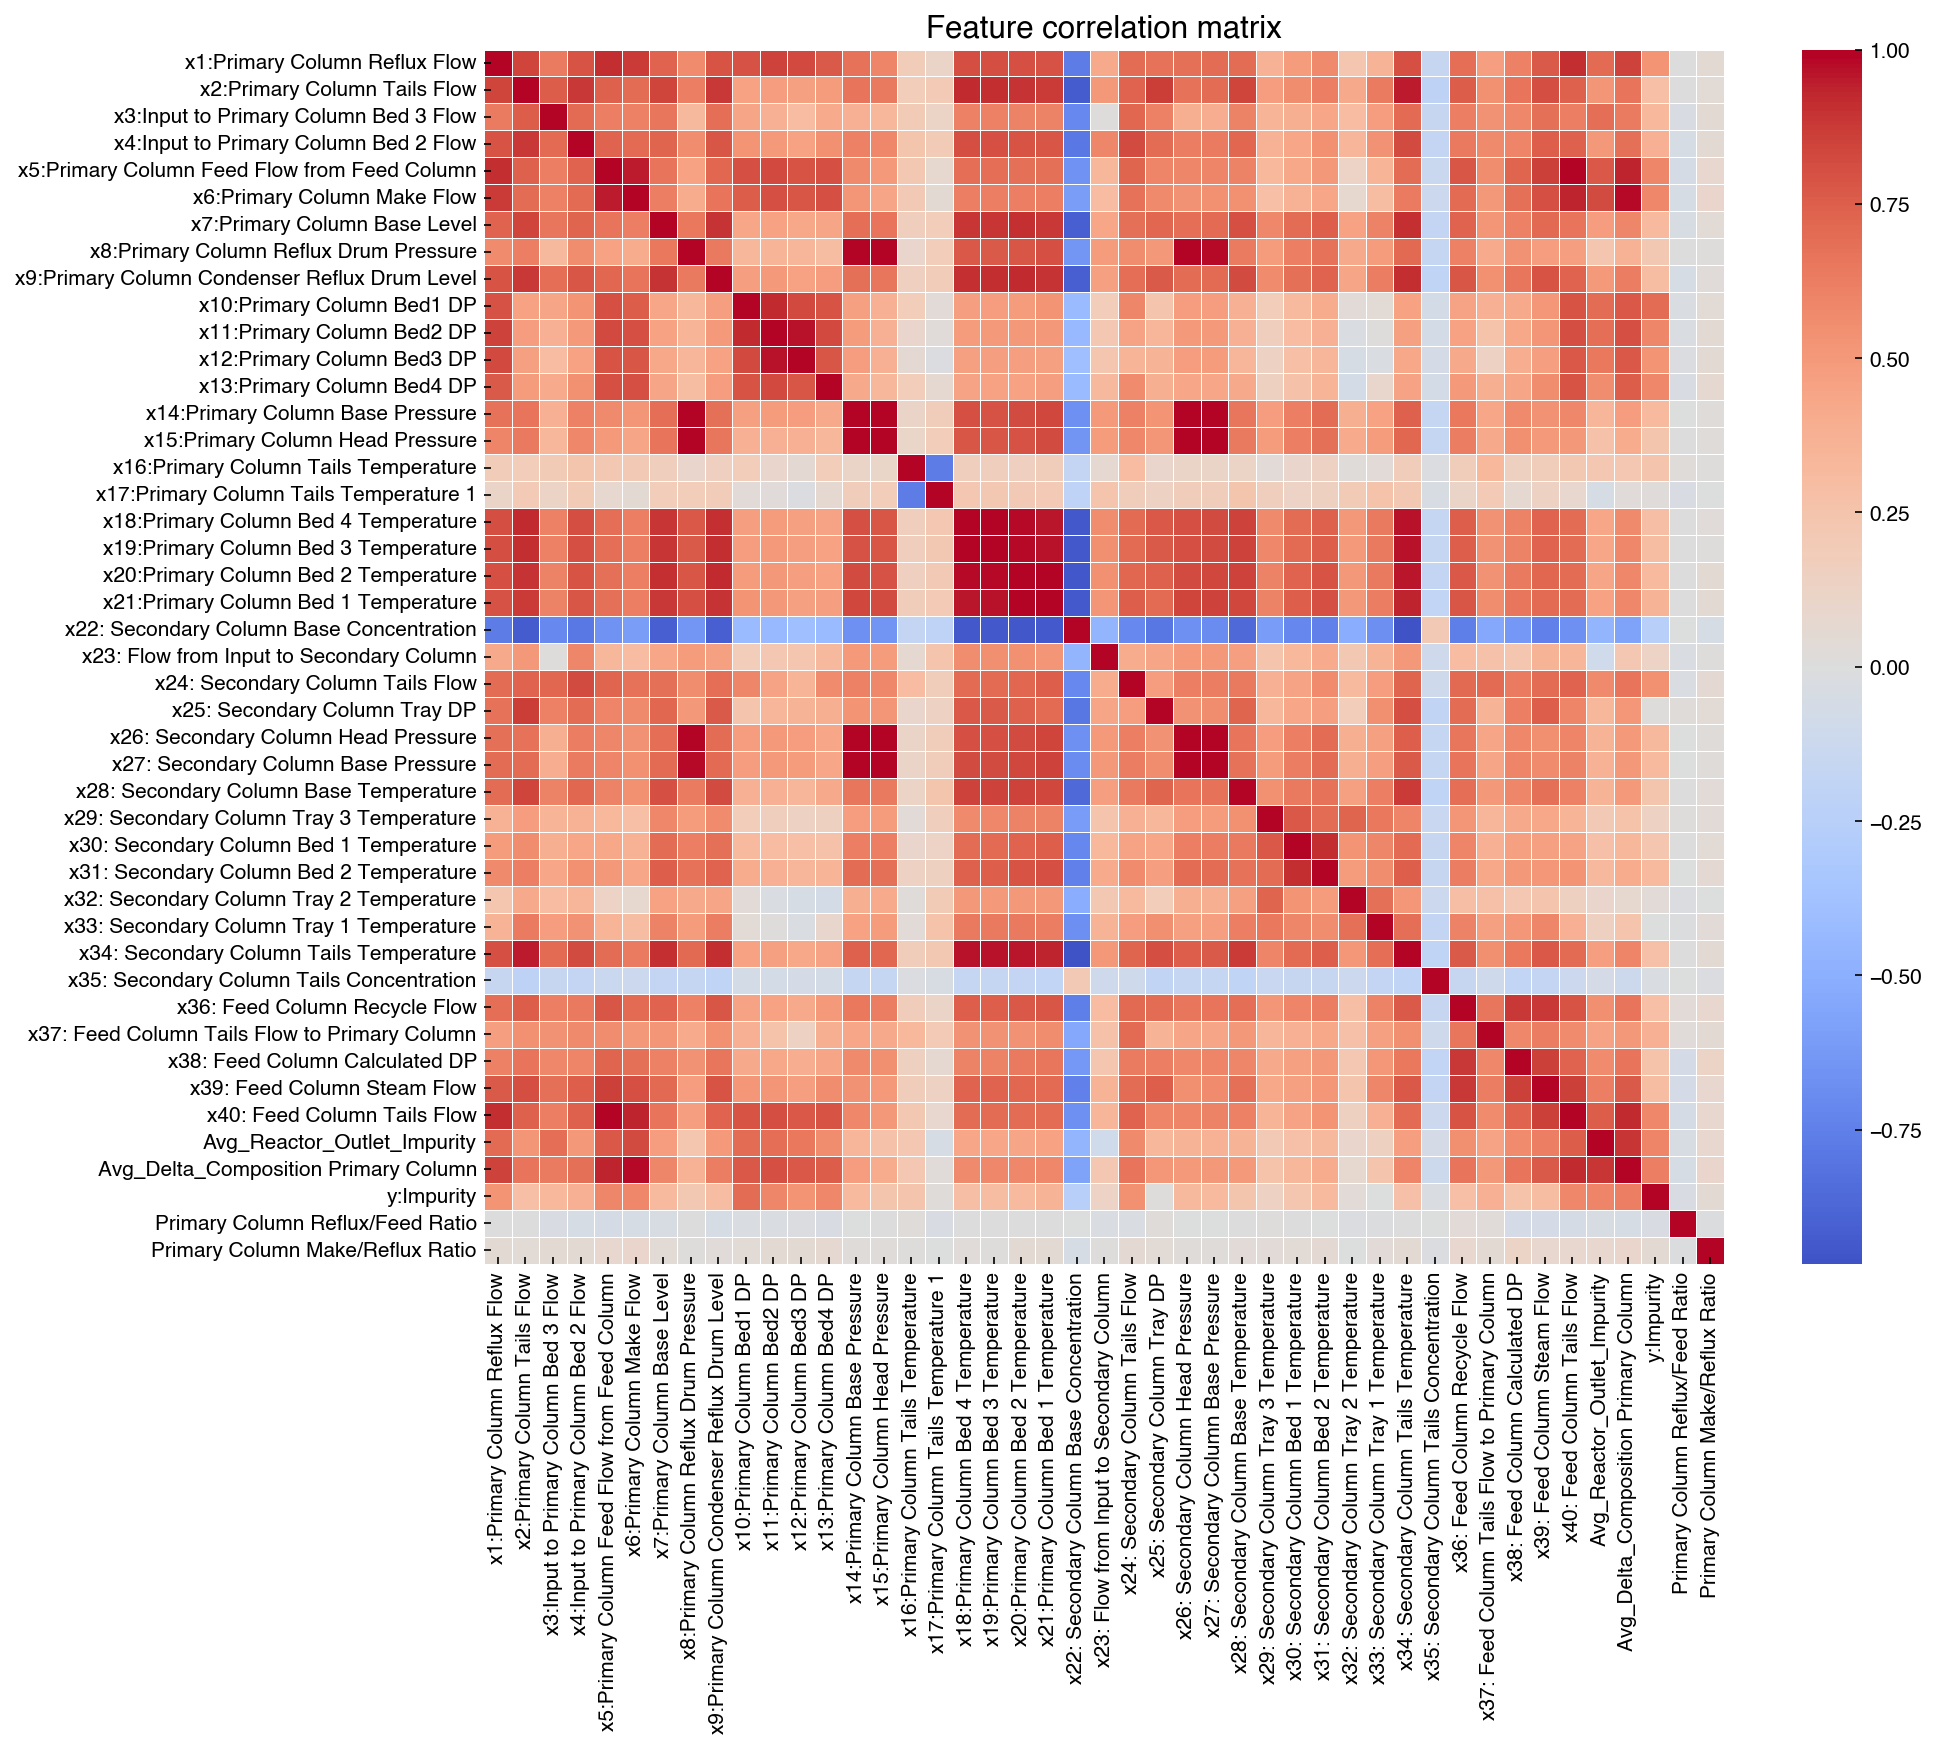

In [17]:
# Columns still have object dtype after filtering; cast explicitly for corr
numeric_only = df_dropped.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
corr = numeric_only.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0,
            linewidths=0.3, annot=False)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

In [18]:
target_col = 'Avg_Delta_Composition Primary Column'
high_corr = corr[target_col][corr[target_col] > 0.95]
print(f'Features highly correlated with "{target_col}":\n{high_corr}')

Features highly correlated with "Avg_Delta_Composition Primary Column":
x6:Primary Column Make Flow             0.977973
Avg_Delta_Composition Primary Column    1.000000
Name: Avg_Delta_Composition Primary Column, dtype: float64


`Primary Column Make Flow` is essentially a linear proxy for
`Avg_Delta_Composition Primary Column`, so we can safely drop the latter without
losing predictive information. In general, keeping both highly correlated features
can cause numerical instability in models that invert the feature matrix (e.g., OLS)
and can make regularization hyperparameter tuning less interpretable.

In [19]:
df_no_avg = df_dropped.drop(columns=[target_col])
print(f'Shape after dropping redundant column: {df_no_avg.shape}')

Shape after dropping redundant column: (10297, 45)


### Imputation

Sometimes dropping rows or columns discards too much data. **Imputation** fills in
missing values using information from the rest of the dataset.

A simple approach uses the linear relationship between two correlated features to
predict the missing values in one from the other:

In [20]:
from sklearn.linear_model import LinearRegression

# Predict Avg_Delta_Composition from x6 (Make Flow) — high corr seen above
x_train = pd.to_numeric(df_dropped['x6:Primary Column Make Flow']).values.reshape(-1, 1)
y_train = pd.to_numeric(df_dropped['Avg_Delta_Composition Primary Column']).values

reg = LinearRegression().fit(x_train, y_train)
print(f'R² for imputation model: {reg.score(x_train, y_train):.3f}')

R² for imputation model: 0.956


:::{note}
The choice of missing-value strategy has significant downstream effects on model
performance. Dropping observations is safe when missingness is rare and random.
Dropping features by correlation is justified when two columns are near-perfectly
correlated. Imputation via regression is powerful but introduces model assumptions;
always validate that the imputation model is accurate before using it.
A common mistake is to fit an imputation model on the **full** dataset (including
test data), which leaks future information into training. Fit imputation models
only on training data.
:::

:::{exercise}
:label: ex-dm-mean-impute

Using `df_dropped`, create a copy of the DataFrame where any `NaN` or non-numeric
value (after converting to float with `pd.to_numeric(..., errors='coerce')`) is
replaced with the **column mean**. Use `DataFrame.fillna()`. Print the count of
remaining null values to confirm the result is complete.
:::

:::{note}
**Connecting cleaning to the modeling pipeline.** Every cleaning step applied to
training data must be identically applied to any new data at inference time —
otherwise the model sees data in a different form than it was trained on. A common
mistake is to compute, say, the column mean for imputation on the full dataset
(including test rows) and then use that mean to fill training rows. This leaks
future information. `sklearn.pipeline.Pipeline` solves this cleanly: wrap each
cleaning step as a `Transformer` (with `fit` on training data only and `transform`
applied to both), and the pipeline ensures correct train/test separation
automatically. This pattern is not explored further here but is worth adopting in
any real project.
:::

---

## Outlier Detection

The general definition of an outlier is a datapoint that was not created by the
same underlying process. However, in practice this definition is not always
helpful, since it requires knowledge of the mechanism that generated the data.
We will not delve into advanced outlier detection methods here, but show a few
simple examples that are commonly used in practice.

### The Z-score Method

An outlier is an observation that deviates unusually far from the bulk of the data.
The **z-score** measures how many standard deviations a point is from the mean:

$$z_i = \frac{x_i - \mu}{\sigma}$$

Points with $|z_i| > z_\text{cutoff}$ (commonly 3) are flagged as outliers under
the assumption that the data follows a Gaussian distribution.

In [21]:
# Demonstrate on a single column
col = 'x3:Input to Primary Column Bed 3 Flow'
xi = pd.to_numeric(df_dropped[col], errors='coerce').dropna()
mu, sigma = xi.mean(), xi.std()
z_cutoff = 3

z_scores = (xi - mu) / sigma
outlier_mask = z_scores.abs() > z_cutoff
xi_clean = xi[~outlier_mask]

print(f'Column: {col}')
print(f'  Total rows:   {len(xi)}')
print(f'  Outliers:     {outlier_mask.sum()}')
print(f'  Retained:     {len(xi_clean)}')

Column: x3:Input to Primary Column Bed 3 Flow
  Total rows:   10297
  Outliers:     307
  Retained:     9990


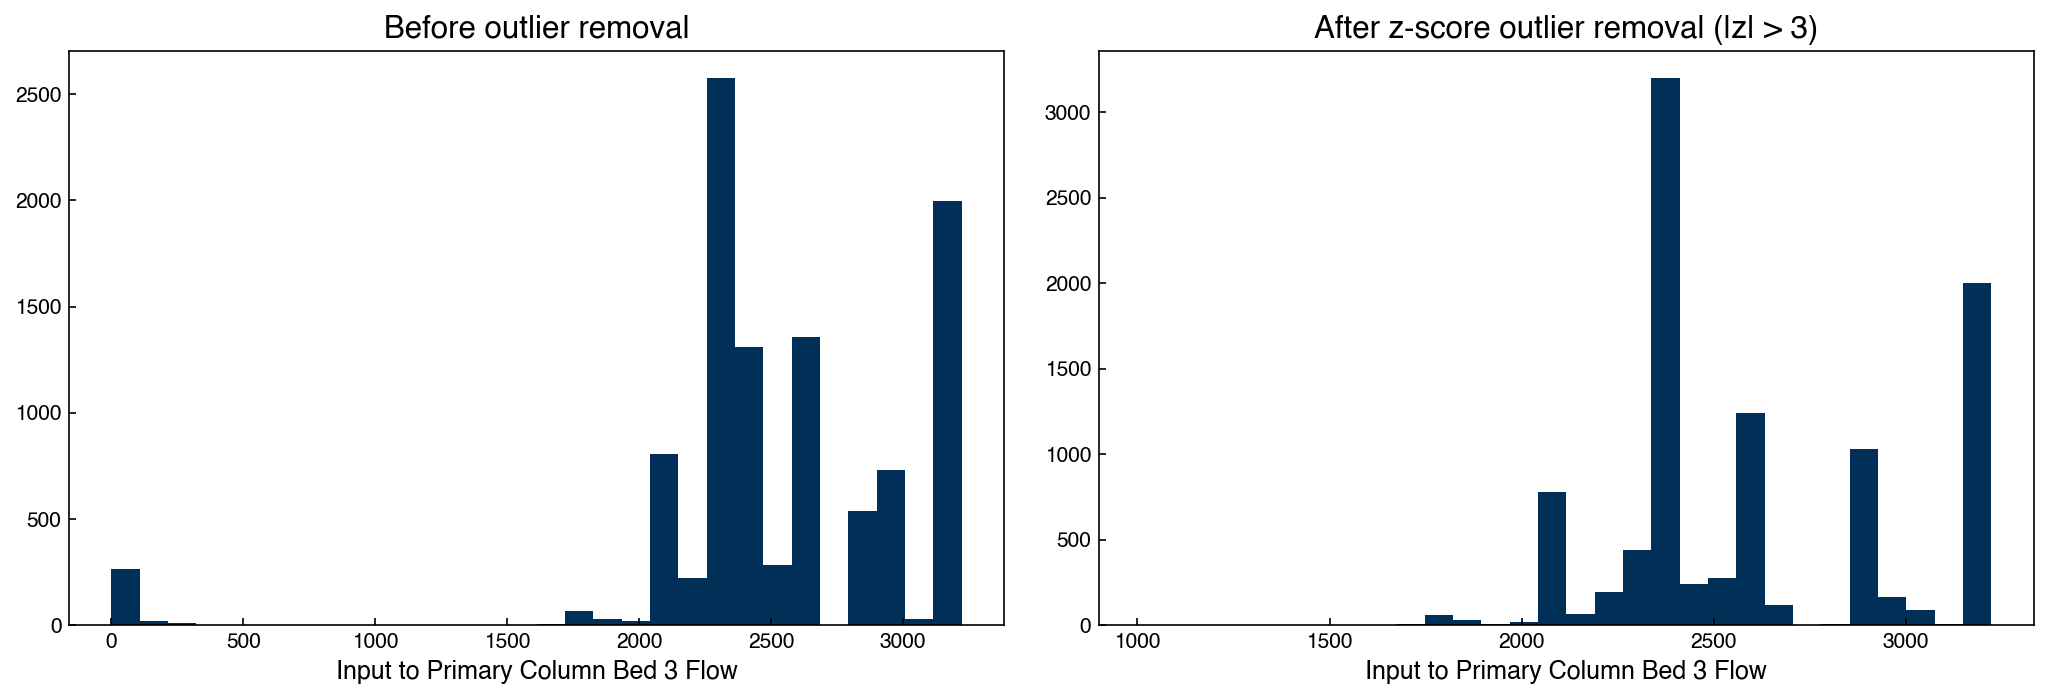

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(xi.values, bins=30)
axes[0].set_title('Before outlier removal')
axes[0].set_xlabel(col.split(':')[1])

axes[1].hist(xi_clean.values, bins=30)
axes[1].set_title('After z-score outlier removal (|z| > 3)')
axes[1].set_xlabel(col.split(':')[1])

plt.tight_layout()
plt.show()

### Demonstration: Applying Z-score to All Columns

In [23]:
df_no_outliers = df_dropped.copy()
z_cutoff = 3

for col in df_dropped.columns[1:]:   # skip 'Date'
    try:
        xi = pd.to_numeric(df_no_outliers[col], errors='coerce')
        mu, sigma = xi.mean(), xi.std()
        if sigma == 0:
            continue
        z_scores = (xi - mu) / sigma
        df_no_outliers = df_no_outliers[z_scores.abs() <= z_cutoff]
    except Exception:
        pass

print(f'Before: {df_dropped.shape[0]} rows')
print(f'After:  {df_no_outliers.shape[0]} rows  '
      f'({df_dropped.shape[0]-df_no_outliers.shape[0]} removed)')

Before: 10297 rows
After:  8042 rows  (2255 removed)


The z-score method assumes that the data are approximately Gaussian and evaluates
each feature independently. For variables with discrete or heavily skewed
distributions, IQR-based filtering is more robust.

:::{exercise}
:label: ex-dm-iqr-outlier

Implement an **IQR-based** outlier filter as an alternative to z-score.
For a single column `x1:Primary Column Reflux Flow`:
1. Compute Q1 (25th percentile), Q3 (75th percentile), and IQR = Q3 − Q1.
2. Flag points outside $[\text{Q1} - 1.5 \cdot \text{IQR},\ \text{Q3} + 1.5 \cdot \text{IQR}]$.
3. Plot histograms before and after removal.
4. Compare the number of outliers flagged by IQR vs. z-score (cutoff = 3) for this column.
:::

### Multivariate Outlier Detection

Z-score and IQR methods examine each feature in isolation. A point can look
perfectly normal on every individual feature while being a genuine **multivariate
outlier** — sitting in a region of joint feature space that never occurs in real
data. For example, a very high reflux flow combined with a very low feed flow
might be individually plausible but operationally impossible together.

Two scikit-learn tools detect multivariate outliers:

- **`EllipticEnvelope`** (`sklearn.covariance.EllipticEnvelope`) fits a Gaussian
  model to the joint distribution. It uses the **Mahalanobis distance**, which
  accounts for feature correlations — so two features that are individually
  normal but jointly impossible are correctly flagged. It works best when the
  data are approximately elliptically distributed.
- **`IsolationForest`** (`sklearn.ensemble.IsolationForest`) is a non-parametric
  alternative that isolates anomalies by recursively partitioning the feature
  space with random splits. Points that are easy to isolate (requiring few splits)
  are anomalous. It scales well to high dimensions without distributional
  assumptions.

### Demonstration: Multivariate Outlier Detection

:::{note}
Both `EllipticEnvelope` and `IsolationForest` require a `contamination` parameter, which specifies the **expected fraction of outliers in the dataset** (a number between 0 and 0.5). This value is set by the analyst based on domain knowledge or prior inspection of the data. A value of `0.05` tells the model to treat the 5% of points with the most anomalous scores as outliers and the remaining 95% as inliers. Choosing `contamination` too high flags clean data as anomalous; too low misses real outliers. In exploratory analysis, it is common to try a few values (e.g. 0.01, 0.05, 0.10) and inspect the flagged points for reasonableness.
:::

In [24]:
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
import numpy as np

# Use the two reflux/feed columns as a 2D example
cols_2d = ['x1:Primary Column Reflux Flow', 'x3:Input to Primary Column Bed 3 Flow']
X2 = df_no_outliers[cols_2d].apply(pd.to_numeric, errors='coerce').dropna()

# EllipticEnvelope: fits a robust Gaussian and flags points outside the
# contamination fraction (5%) as outliers
ee = EllipticEnvelope(contamination=0.05, random_state=0)
ee_labels = ee.fit_predict(X2)   # +1 = inlier, -1 = outlier

# IsolationForest: tree-based anomaly score, no distributional assumption
iso = IsolationForest(contamination=0.05, random_state=0)
iso_labels = iso.fit_predict(X2)  # +1 = inlier, -1 = outlier

print(f'EllipticEnvelope: {(ee_labels == -1).sum()} outliers flagged')
print(f'IsolationForest:  {(iso_labels == -1).sum()} outliers flagged')
print(f'Agreement (both flag as outlier): {((ee_labels == -1) & (iso_labels == -1)).sum()}')

EllipticEnvelope: 403 outliers flagged
IsolationForest:  403 outliers flagged
Agreement (both flag as outlier): 245


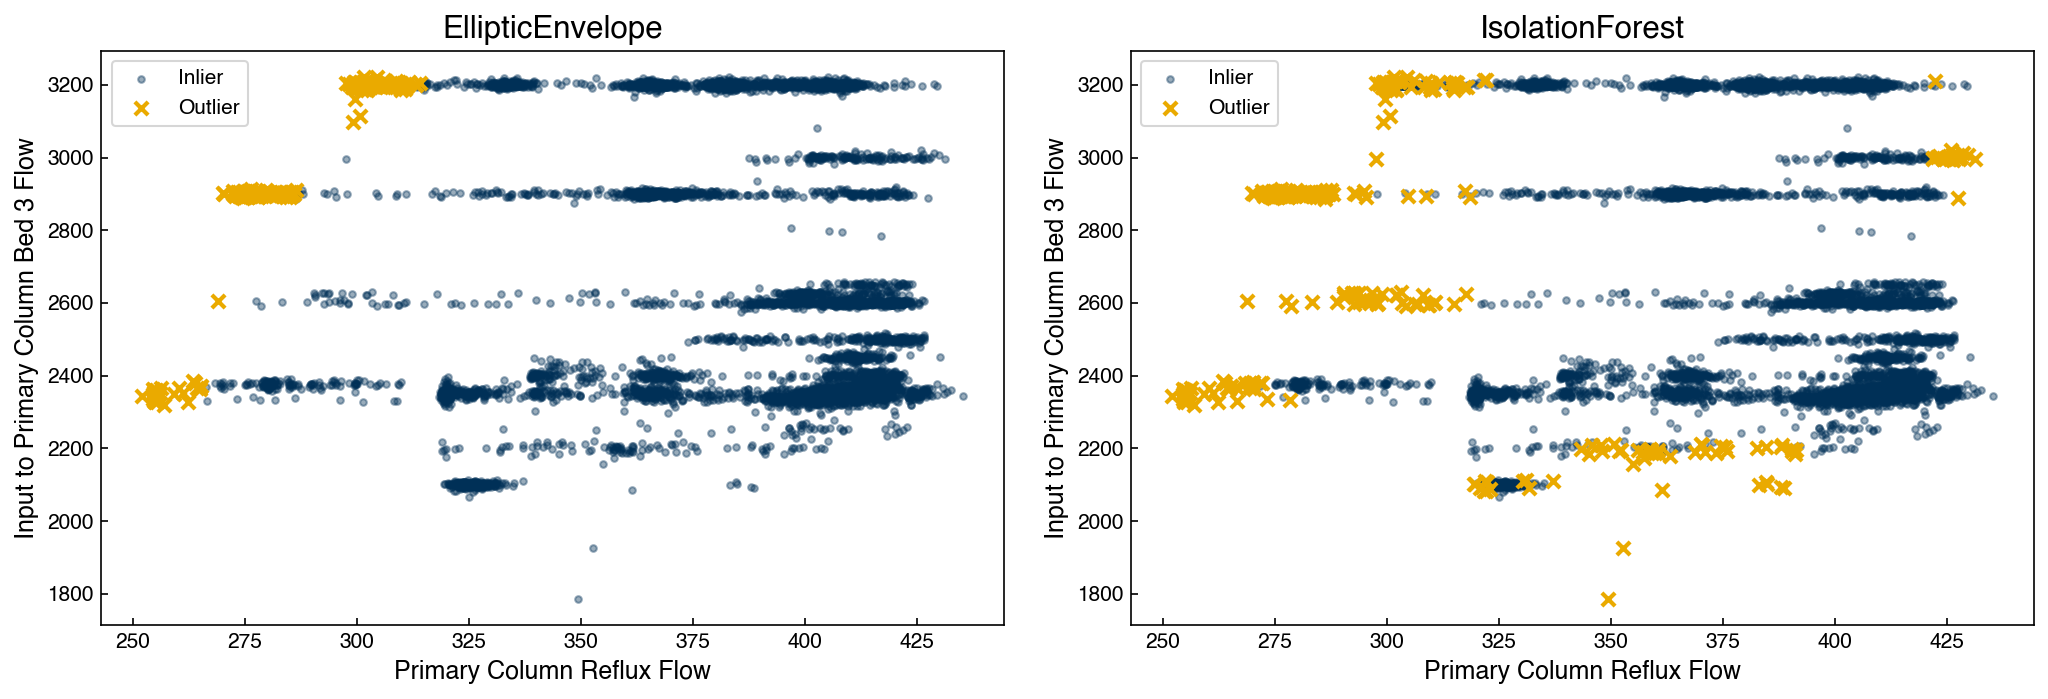

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(
    axes,
    [ee_labels, iso_labels],
    ['EllipticEnvelope', 'IsolationForest'],
):
    inliers  = X2[labels ==  1]
    outliers = X2[labels == -1]
    ax.scatter(inliers.iloc[:, 0],  inliers.iloc[:, 1],
               c=clrs[0], s=10, alpha=0.4, label='Inlier')
    ax.scatter(outliers.iloc[:, 0], outliers.iloc[:, 1],
               c=clrs[1], s=40, marker='x', label='Outlier')
    ax.set_xlabel(cols_2d[0].split(':')[1])
    ax.set_ylabel(cols_2d[1].split(':')[1])
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

:::{exercise}
:label: ex-dm-multivar-outlier

Apply `IsolationForest` to the **full numeric feature matrix** of `df_no_outliers`
(all columns except `Date`) with `contamination=0.05`.

1. How many rows are flagged as outliers across all features?
2. Inspect the flagged rows — think about whether these rows look unusual compared
   to the bulk of the data.
3. How does the count compare to applying z-score (cutoff = 3) column-by-column?
:::

---

## Efficient Data Storage

### Why File Format Matters

The Dow dataset is small enough to load from Excel in a few seconds. For real
process data — which may span months of high-frequency sensor readings at one-second
intervals, easily reaching millions of rows — loading an Excel or CSV file at the
start of every analysis session becomes impractical. A 10 GB CSV that takes 3 minutes
to load and parse effectively prevents interactive exploration. Choosing an appropriate
file format is an engineering decision with real consequences for workflow efficiency.

The three main properties to consider are **read speed**, **write speed**, and
**partial-read support** (the ability to load a subset of rows or columns without
reading the entire file). Text formats like CSV have none of these; binary formats
like HDF5 and Parquet have all three.

In [26]:
import time
start = time.time()
_ = pd.read_excel('data/impurity_dataset-training.xlsx')
print(f'Excel load time: {time.time()-start:.2f} s')

Excel load time: 1.65 s


### HDF5 Files

**HDF5** (Hierarchical Data Format 5) is a binary format designed for large
numerical datasets. Its key advantages are:

- **Fast partial reads** — you can load a single column from a 10 GB file without
  reading the whole thing into memory.
- **Hierarchical structure** — datasets can be organized into groups, like a
  filesystem within a file.
- **Metadata attributes** — descriptive information can be stored alongside the
  data, keeping provenance in one place.

In [27]:
import h5py
from pathlib import Path

hdf_path = Path('data/impurity_data.hdf5')
if hdf_path.exists():
    hdf_path.unlink()   # remove stale file to avoid append errors

In [28]:
# Prepare numeric array (drop Date column, cast object cols to float)
df_numeric = df_no_outliers.iloc[:, 1:].apply(pd.to_numeric, errors='coerce').dropna()
X_dow = df_numeric.values.astype('float')
col_names_dow = list(df_numeric.columns)
print(f'Array shape: {X_dow.shape}')

with h5py.File(hdf_path, 'w') as f:
    dset = f.create_dataset('training', data=X_dow)
    # Store metadata as attributes
    dset.attrs['name']    = 'Dow impurity training set'
    dset.attrs['company'] = 'Dow Chemical'
    dset.attrs['course']  = 'ChBE 4745/6745'
    dset.attrs['columns'] = str(col_names_dow)
    print(f'Dataset stored: shape={dset.shape}, dtype={dset.dtype}')
    print(f'Attributes: {dict(dset.attrs)}')

Array shape: (8042, 45)
Dataset stored: shape=(8042, 45), dtype=float64
Attributes: {'columns': "['x1:Primary Column Reflux Flow', 'x2:Primary Column Tails Flow', 'x3:Input to Primary Column Bed 3 Flow', 'x4:Input to Primary Column Bed 2 Flow', 'x5:Primary Column Feed Flow from Feed Column', 'x6:Primary Column Make Flow', 'x7:Primary Column Base Level', 'x8:Primary Column Reflux Drum Pressure', 'x9:Primary Column Condenser Reflux Drum Level', 'x10:Primary Column Bed1 DP', 'x11:Primary Column Bed2 DP', 'x12:Primary Column Bed3 DP', 'x13:Primary Column Bed4 DP', 'x14:Primary Column Base Pressure', 'x15:Primary Column Head Pressure', 'x16:Primary Column Tails Temperature', 'x17:Primary Column Tails Temperature 1', 'x18:Primary Column Bed 4 Temperature', 'x19:Primary Column Bed 3 Temperature', 'x20:Primary Column Bed 2 Temperature', 'x21:Primary Column Bed 1 Temperature', 'x22: Secondary Column Base Concentration', 'x23: Flow from Input to Secondary Column', 'x24: Secondary Column Tails Fl

HDF5 files support hierarchical organization with groups (analogous to folders):

In [29]:
with h5py.File(hdf_path, 'a') as f:
    grp = f.create_group('data_by_feature')
    for i, col in enumerate(col_names_dow):
        ds = grp.create_dataset(col, data=X_dow[:, i])
    print('Groups and datasets:')
    for key in f.keys():
        print(f'  /{key}: {f[key]}')

Groups and datasets:
  /data_by_feature: <HDF5 group "/data_by_feature" (45 members)>
  /training: <HDF5 dataset "training": shape (8042, 45), type "<f8">


### Timing Comparison

In [30]:
# Full array load from HDF5
start = time.time()
with h5py.File(hdf_path, 'r') as f:
    X_loaded = f['training'][:, :]
print(f'HDF5 full load:   {time.time()-start:.4f} s')

# Single-column load — the real HDF5 advantage
start = time.time()
with h5py.File(hdf_path, 'r') as f:
    x1_col = f['training'][:, 0]
print(f'HDF5 one column:  {time.time()-start:.4f} s')

# In-memory access for comparison
start = time.time()
_ = X_dow[:, 0]
print(f'In-memory slice:  {time.time()-start:.6f} s')

HDF5 full load:   0.0006 s
HDF5 one column:  0.0003 s
In-memory slice:  0.000114 s


:::{note}
HDF5's selective-read advantage becomes significant only for datasets that are too
large to fit in RAM. For the datasets in this course (thousands to tens of thousands
of rows), the speed difference is small. However, building good HDF5 habits now
pays dividends when you encounter GB- or TB-scale industrial process data in practice.
HDF5 is also deeply embedded in scientific computing workflows — NetCDF (climate/ocean
data), PyTables, and many HPC file systems build on the HDF5 specification.
:::

### Modern Alternatives: Parquet

**Parquet** is a columnar binary format developed by Apache that has become the
de facto standard for analytical data pipelines outside of scientific computing.
Unlike HDF5, Parquet stores schema information (column names and types) natively,
handles mixed dtypes (including strings and timestamps) without manual conversion,
and integrates directly with cloud data warehouses (BigQuery, Snowflake, Databricks).
It is natively supported by `pandas`, `polars`, `Spark`, and `DuckDB`.

In [31]:
# Write a clean DataFrame to Parquet
df_clean = df_no_outliers.copy()
# Ensure numeric cols are float (Parquet does not accept object dtype numerics)
for col in df_clean.columns[1:]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

start = time.time()
df_clean.to_parquet('data/impurity_clean.parquet', index=False)
print(f'Parquet write: {time.time()-start:.4f} s')

start = time.time()
df_reloaded = pd.read_parquet('data/impurity_clean.parquet')
print(f'Parquet read:  {time.time()-start:.4f} s')

print(f'\nShape preserved: {df_reloaded.shape}')
print(f'Dtypes after round-trip:\n{df_reloaded.dtypes.value_counts()}')

Parquet write: 0.0642 s
Parquet read:  0.0585 s

Shape preserved: (8042, 46)
Dtypes after round-trip:
float64           45
datetime64[ns]     1
Name: count, dtype: int64


Other modern formats worth knowing:

| Format | Best for | Key advantage |
|---|---|---|
| **Parquet** | Tabular DataFrames | Schema metadata, columnar reads, cloud-native |
| **Feather / Arrow** | In-process exchange | Near-zero serialization overhead |
| **Zarr** | Multi-dimensional arrays | Cloud-native, concurrent writes, chunked storage |
| **LMDB** | Key-value lookups | Memory-mapped, extremely fast random reads; widely used in machine learning data loaders (PyTorch, TensorFlow) |
| **HDF5** | Scientific numerical arrays | Hierarchical, mature ecosystem, partial reads |

:::{exercise}
:label: ex-dm-parquet

Compare the file sizes of `impurity_data.hdf5` and `impurity_clean.parquet`
using `Path('data/...').stat().st_size`. Then use `pd.read_parquet()` to load
only two numeric feature columns and the target `y` (Parquet supports column
selection natively via the `columns=` argument). Print the shape and compare
the read time to the full-file HDF5 read above.
:::

---

## Summary

- **Tidy data** (Wickham, 2014): each variable is a column, each observation is
  a row, each observational unit is a table. Most pandas operations assume this
  structure; arriving in tidy form avoids many downstream headaches.
  `pd.melt()` and `pd.pivot()` are the primary reshape tools when data is untidy.

- **Data validation** — checking dtypes, value ranges, and null counts immediately
  after loading — catches silent data quality issues before they corrupt downstream
  analysis. Libraries like pandera and great_expectations automate this in production.

- **Pandas** provides flexible tools for indexing (`.loc`, `.iloc`, boolean masks),
  renaming, and datetime-based slicing. Setting a datetime column as the index
  enables natural time-range queries.

- **Missing values** in industrial data rarely appear as simple `NaN` — custom
  detection functions are often needed. Strategies include dropping problematic
  rows or columns, and regression imputation. All cleaning must be fit on training
  data only; `sklearn.pipeline.Pipeline` enforces this automatically.

- **Correlation analysis** identifies redundant features that can be removed without
  information loss, reducing model complexity and preventing numerical issues.

- **Outlier detection** with z-scores is simple but assumes Gaussian, independent
  variables. For high-dimensional or non-Gaussian data, consider IQR bounds,
  Mahalanobis distance (`EllipticEnvelope`), or Isolation Forest.

- **HDF5** excels for large numerical arrays: hierarchical structure, metadata
  attributes, and fast partial reads. **Parquet** is the modern default for tabular
  DataFrames: schema metadata, native mixed-dtype support, and cloud integration.
  **LMDB** is a strong choice for key-value data in machine learning pipelines.

## Additional Reading

- McKinney, W., *Python for Data Analysis* (3rd ed.) — the definitive pandas
  reference, covering indexing, missing data, and I/O in depth
- Wickham, H. (2014), "Tidy Data," *Journal of Statistical Software* 59(10) —
  foundational principles for organizing tabular data; [free PDF](https://doi.org/10.18637/jss.v059.i10)
- The HDF Group, [HDF5 User's Guide](https://docs.hdfgroup.org/hdf5/develop/index.html)
- Apache Parquet, [Parquet Format Specification](https://parquet.apache.org/docs/)
- pandas documentation:
  [Indexing](https://pandas.pydata.org/docs/user_guide/indexing.html),
  [Missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html),
  [IO tools](https://pandas.pydata.org/docs/user_guide/io.html)